### 1. Introduction

This notebook prepares the Retailrocket event data for session-level modelling. The preprocessing stage focuses on removing duplicate event records, ordering interactions chronologically, constructing user sessions based on periods of inactivity, and transforming event-level observations into session-level features.

The resulting session-level dataset will subsequently be used to define the binary conversion outcome and provide the input variables required for Bayesian Network and baseline modelling.

### 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 3. Load Event Data

The event dataset contains the behavioural interactions required for session construction, including visitor identifiers, event types, item identifiers, transaction identifiers and timestamps. The raw event data are loaded independently to ensure that preprocessing steps performed in this notebook are reproducible.

In [2]:
events = pd.read_csv("../data/raw/events.csv")

print(f"Initial number of events: {len(events):,}")
events.head()

Initial number of events: 2,756,101


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


### 4. Preprocessing

Before constructing sessions, the event data were prepared by removing exact duplicate records, converting timestamps to datetime format and ordering interactions chronologically within each visitor. These steps ensure that subsequent session boundaries are based on correctly ordered behavioural events.

#### 4.1 Remove Duplicate Records

The initial data quality assessment identified 460 exact duplicate records within the event dataset. These records were removed before session construction to prevent repeated observations from artificially increasing event counts or influencing session-level features.

In [3]:
print(f"Rows before duplicate removal: {len(events):,}")

events = events.drop_duplicates().copy()

print(f"Rows after duplicate removal: {len(events):,}")

Rows before duplicate removal: 2,756,101
Rows after duplicate removal: 2,755,641


#### 4.2 Timestamp Conversion

Event timestamps are stored as Unix timestamps measured in milliseconds. They were converted to datetime format to enable calculation of the elapsed time between consecutive visitor interactions.

In [4]:
events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    unit="ms"
)

events[["timestamp"]].head()

,timestamp
0,2015-06-02 05:02:12.117
1,2015-06-02 05:50:14.164
2,2015-06-02 05:13:19.827
3,2015-06-02 05:12:35.914
4,2015-06-02 05:02:17.106


#### 4.3 Chronological Ordering

Events were ordered by visitor identifier and timestamp so that each visitor's interactions occurred in chronological sequence. This allows the time elapsed between consecutive interactions to be calculated accurately and subsequently used to identify session boundaries.

In [5]:
events = (
    events
    .sort_values(["visitorid", "timestamp"])
    .reset_index(drop=True)
)

events.head()

,timestamp,visitorid,event,itemid,transactionid
0,2015-09-11 20:49:49.439,0,view,285930,NaN
1,2015-09-11 20:52:39.591,0,view,357564,NaN
2,2015-09-11 20:55:17.175,0,view,67045,NaN
3,2015-08-13 17:46:06.444,1,view,72028,NaN
4,2015-08-07 17:51:44.567,2,view,325215,NaN


In [6]:
events[["visitorid", "timestamp", "event", "itemid"]].head(10)

,visitorid,timestamp,event,itemid
0,0,2015-09-11 20:49:49.439,view,285930
1,0,2015-09-11 20:52:39.591,view,357564
2,0,2015-09-11 20:55:17.175,view,67045
3,1,2015-08-13 17:46:06.444,view,72028
4,2,2015-08-07 17:51:44.567,view,325215
5,2,2015-08-07 17:53:33.790,view,325215
6,2,2015-08-07 17:56:52.664,view,259884
7,2,2015-08-07 18:01:08.920,view,216305
8,2,2015-08-07 18:08:25.669,view,342816
9,2,2015-08-07 18:17:24.375,view,342816


### 5. Investigating Session Boundaries

Session construction requires a rule for determining when a sequence of interactions from the same visitor represents a new session. To inform this decision, the time elapsed between consecutive events belonging to each visitor was calculated.

Examining the empirical distribution of inactivity periods provides context for selecting an appropriate session inactivity threshold rather than relying solely on an arbitrary value.

In [7]:
events["time_since_previous_event"] = (
    events.groupby("visitorid")["timestamp"]
          .diff()
)

events["minutes_since_previous_event"] = (
    events["time_since_previous_event"].dt.total_seconds() / 60
)

events[
    ["visitorid", "timestamp", "event", "minutes_since_previous_event"]
].head(20)

,visitorid,timestamp,event,minutes_since_previous_event
0,0,2015-09-11 20:49:49.439,view,NaN
1,0,2015-09-11 20:52:39.591,view,2.835867
2,0,2015-09-11 20:55:17.175,view,2.626400
3,1,2015-08-13 17:46:06.444,view,NaN
4,2,2015-08-07 17:51:44.567,view,NaN
5,2,2015-08-07 17:53:33.790,view,1.820383
6,2,2015-08-07 17:56:52.664,view,3.314567
7,2,2015-08-07 18:01:08.920,view,4.270933
8,2,2015-08-07 18:08:25.669,view,7.279150
9,2,2015-08-07 18:17:24.375,view,8.978433


In [8]:
events["minutes_since_previous_event"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.348061e+06
mean     3.571735e+03
std      1.506845e+04
min      0.000000e+00
25%      6.381500e-01
50%      2.275900e+00
75%      4.091795e+01
90%      4.394826e+03
95%      1.984828e+04
99%      8.601642e+04
max      1.964575e+05
Name: minutes_since_previous_event, dtype: float64

#### 5.1 Inactivity Gap Distribution

The descriptive statistics indicate a highly right-skewed distribution of inactivity periods. While the median interval between consecutive events is approximately 2.3 minutes, the 75th percentile increases to approximately 40.9 minutes, with substantially larger intervals at higher percentiles. This suggests that the data contain both short within-session interactions and longer periods representing separate visits.

To examine potential session boundaries more closely, the distribution of shorter inactivity periods was analysed separately.

In [9]:
short_gaps = events.loc[
    events["minutes_since_previous_event"].between(0, 180),
    "minutes_since_previous_event"
]

short_gaps.describe(
    percentiles=[0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
)

count    1.070999e+06
mean     8.455757e+00
std      2.264875e+01
min      0.000000e+00
50%      1.321983e+00
60%      1.995713e+00
70%      3.237750e+00
75%      4.361233e+00
80%      6.273637e+00
85%      1.001266e+01
90%      1.887651e+01
95%      4.669281e+01
max      1.799983e+02
Name: minutes_since_previous_event, dtype: float64

In [10]:
valid_gaps = events["minutes_since_previous_event"].dropna()

for threshold in [15, 30, 45, 60, 90, 120]:
    percentage = valid_gaps.le(threshold).mean() * 100
    
    print(
        f"Gap ≤ {threshold:3} minutes: "
        f"{percentage:.2f}% of observed consecutive-event gaps"
    )

Gap ≤  15 minutes: 70.21% of observed consecutive-event gaps
Gap ≤  30 minutes: 73.73% of observed consecutive-event gaps
Gap ≤  45 minutes: 75.34% of observed consecutive-event gaps
Gap ≤  60 minutes: 76.33% of observed consecutive-event gaps
Gap ≤  90 minutes: 77.58% of observed consecutive-event gaps
Gap ≤ 120 minutes: 78.39% of observed consecutive-event gaps


The analysis indicates that most consecutive interactions occur within relatively short periods of inactivity. Approximately 73.7% of observed consecutive-event gaps are no greater than 30 minutes. Increasing the threshold beyond 30 minutes results in progressively smaller increases in the proportion of interactions retained within the same potential session; for example, thresholds of 45 and 60 minutes capture approximately 75.3% and 76.3% of gaps, respectively.

These findings suggest that a 30-minute inactivity threshold provides a reasonable initial boundary between continuous browsing activity and returning visits. However, the final threshold selection should also be supported by established approaches within clickstream and session-based research.

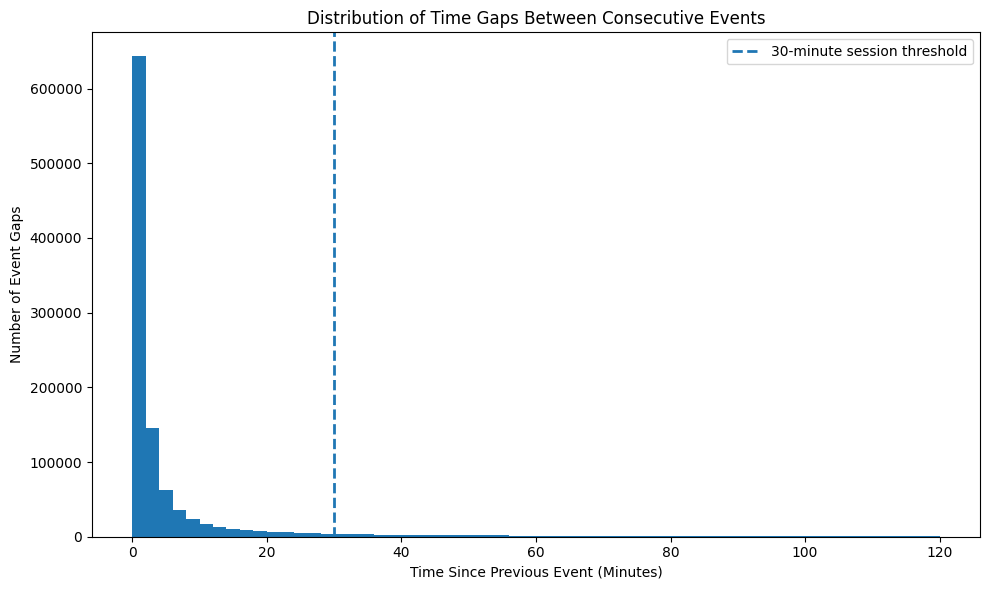

In [11]:
# Visualise shorter inactivity gaps between consecutive events
short_gaps = events.loc[
    events["minutes_since_previous_event"].between(0, 120),
    "minutes_since_previous_event"
]

plt.figure(figsize=(10, 6))

plt.hist(
    short_gaps,
    bins=60
)

# Show selected 30-minute session threshold
plt.axvline(
    x=30,
    linestyle="--",
    linewidth=2,
    label="30-minute session threshold"
)

plt.title("Distribution of Time Gaps Between Consecutive Events")
plt.xlabel("Time Since Previous Event (Minutes)")
plt.ylabel("Number of Event Gaps")
plt.legend()

plt.tight_layout()

# Save for dissertation
plt.savefig(
    "../figures/results/time_gap_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 5.2 Session Threshold Selection

A 30-minute inactivity threshold was selected for session construction. Under this approach, consecutive events generated by the same visitor are considered part of the same session when the period of inactivity between them does not exceed 30 minutes. An inactivity period greater than 30 minutes therefore indicates the beginning of a new session.

The selection of this threshold was informed by both established web analytics practice and the empirical distribution of inactivity periods within the Retailrocket dataset. A 30-minute inactivity threshold is commonly used for session identification in web analytics and web usage mining. However, as the appropriate threshold may depend on the characteristics of the application and user behaviour, the distribution of inactivity periods within the dataset was also considered.

The empirical analysis showed that the median interval between consecutive events was approximately 2.3 minutes and that most short-term interactions occurred within substantially less than 30 minutes. Approximately 73.7% of all observed consecutive-event gaps were no greater than 30 minutes. Increasing the threshold to 45 or 60 minutes increased this proportion only modestly, to approximately 75.3% and 76.3%, respectively. A 30-minute threshold was therefore considered an appropriate balance between preserving continuous browsing activity and reducing the likelihood of combining distinct visits into a single session.

### 6. Session Construction

User sessions were constructed using a 30-minute inactivity threshold. A new session was defined whenever the time elapsed between consecutive events from the same visitor exceeded 30 minutes. The first recorded event for each visitor was also treated as the start of a new session.

Session identifiers were then assigned sequentially within each visitor to allow event-level interactions to be aggregated into session-level observations for subsequent feature engineering and conversion modelling.

#### 6.1 Identify Session Boundaries

A binary indicator was created to identify the beginning of each new session. An event was classified as the start of a new session when either no previous event existed for the visitor or the inactivity period exceeded 30 minutes.

In [76]:
SESSION_THRESHOLD_MINUTES = 30

events["new_session"] = (
    events["minutes_since_previous_event"].isna()
    | (events["minutes_since_previous_event"] > SESSION_THRESHOLD_MINUTES)
)

events[
    [
        "visitorid",
        "timestamp",
        "event",
        "minutes_since_previous_event",
        "new_session"
    ]
].head(20)

,visitorid,timestamp,event,minutes_since_previous_event,new_session
0,0,2015-09-11 20:49:49.439,view,NaN,True
1,0,2015-09-11 20:52:39.591,view,2.835867,False
2,0,2015-09-11 20:55:17.175,view,2.626400,False
3,1,2015-08-13 17:46:06.444,view,NaN,True
4,2,2015-08-07 17:51:44.567,view,NaN,True
5,2,2015-08-07 17:53:33.790,view,1.820383,False
6,2,2015-08-07 17:56:52.664,view,3.314567,False
7,2,2015-08-07 18:01:08.920,view,4.270933,False
8,2,2015-08-07 18:08:25.669,view,7.279150,False
9,2,2015-08-07 18:17:24.375,view,8.978433,False


#### 6.2 Assign Session Numbers

Session numbers were assigned separately within each visitor by cumulatively counting the identified session boundaries. This produces a sequential session number for each visitor while preserving the chronological order of interactions.

In [77]:
events["visitor_session_number"] = (
    events.groupby("visitorid")["new_session"].cumsum()
)

In [78]:
events[
    [
        "visitorid",
        "timestamp",
        "event",
        "minutes_since_previous_event",
        "new_session",
        "visitor_session_number"
    ]
].head(30)

,visitorid,timestamp,event,minutes_since_previous_event,new_session,visitor_session_number
0,0,2015-09-11 20:49:49.439,view,NaN,True,1
1,0,2015-09-11 20:52:39.591,view,2.835867,False,1
2,0,2015-09-11 20:55:17.175,view,2.626400,False,1
3,1,2015-08-13 17:46:06.444,view,NaN,True,1
4,2,2015-08-07 17:51:44.567,view,NaN,True,1
5,2,2015-08-07 17:53:33.790,view,1.820383,False,1
6,2,2015-08-07 17:56:52.664,view,3.314567,False,1
7,2,2015-08-07 18:01:08.920,view,4.270933,False,1
8,2,2015-08-07 18:08:25.669,view,7.279150,False,1
9,2,2015-08-07 18:17:24.375,view,8.978433,False,1


#### 6.3 Create Unique Session Identifiers

A unique session identifier was created by combining each visitor identifier with the visitor-specific session number. This ensures that every reconstructed session can be uniquely identified across the dataset.

In [79]:
events["session_id"] = (
    events["visitorid"].astype(str)
    + "_"
    + events["visitor_session_number"].astype(str)
)

events[
    ["visitorid", "visitor_session_number", "session_id"]
].head(10)

,visitorid,visitor_session_number,session_id
0,0,1,0_1
1,0,1,0_1
2,0,1,0_1
3,1,1,1_1
4,2,1,2_1
5,2,1,2_1
6,2,1,2_1
7,2,1,2_1
8,2,1,2_1
9,2,1,2_1


#### 6.4 Initial Session Counts

The total number of reconstructed sessions and the number of sessions per visitor were calculated to provide an initial assessment of the sessionisation output.

In [80]:
total_sessions = events["session_id"].nunique()

sessions_per_visitor = (
    events.groupby("visitorid")["session_id"].nunique()
)

print(f"Total sessions: {total_sessions:,}")
print(f"Unique visitors: {events['visitorid'].nunique():,}")
print(f"Mean sessions per visitor: {sessions_per_visitor.mean():.2f}")
print(f"Median sessions per visitor: {sessions_per_visitor.median():.2f}")
print(f"Maximum sessions for one visitor: {sessions_per_visitor.max():,}")

Total sessions: 1,761,675
Unique visitors: 1,407,580
Mean sessions per visitor: 1.25
Median sessions per visitor: 1.00
Maximum sessions for one visitor: 462


#### 6.5 Session Validation

The reconstructed sessions were inspected to confirm that events separated by no more than 30 minutes remained within the same session, while inactivity periods greater than 30 minutes generated a new session.

In [81]:
multi_session_visitors = (
    sessions_per_visitor[sessions_per_visitor > 1]
    .sort_values(ascending=False)
)

multi_session_visitors.head(10)

visitorid
316850     462
825321     417
895999     414
638482     353
518659     302
1126569    282
229157     279
530559     269
85734      267
1165148    264
Name: session_id, dtype: int64

In [82]:
example_visitor = multi_session_visitors.index[0]

events.loc[
    events["visitorid"] == example_visitor,
    [
        "visitorid",
        "timestamp",
        "event",
        "minutes_since_previous_event",
        "new_session",
        "visitor_session_number",
        "session_id"
    ]
].head(50)

,visitorid,timestamp,event,minutes_since_previous_event,new_session,visitor_session_number,session_id
622935,316850,2015-05-03 18:11:11.649,view,NaN,True,1,316850_1
622936,316850,2015-05-03 19:48:42.688,view,97.517317,True,2,316850_2
622937,316850,2015-05-03 21:06:09.005,view,77.438617,True,3,316850_3
622938,316850,2015-05-04 02:27:01.148,view,320.869050,True,4,316850_4
622939,316850,2015-05-04 02:30:19.106,view,3.299300,False,4,316850_4
622940,316850,2015-05-04 13:18:01.351,view,647.704083,True,5,316850_5
622941,316850,2015-05-04 13:28:14.160,view,10.213483,False,5,316850_5
622942,316850,2015-05-04 13:28:56.326,view,0.702767,False,5,316850_5
622943,316850,2015-05-04 13:29:30.031,view,0.561750,False,5,316850_5
622944,316850,2015-05-04 16:04:45.637,view,155.260100,True,6,316850_6


### 7. Session Characteristics

The characteristics of the reconstructed sessions were examined before developing the session-level modelling dataset. This analysis considers session size, duration and behavioural activity to understand how users interact within individual visits and to identify characteristics that may influence subsequent feature engineering.

#### 7.1 Basic Session Statistics

Event-level interactions were aggregated by session to calculate the number of events, session start and end times, session duration and number of unique items interacted with during each reconstructed session.

In [83]:
session_summary = (
    events.groupby("session_id")
    .agg(
        visitorid=("visitorid", "first"),
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        event_count=("event", "size"),
        unique_items=("itemid", "nunique")
    )
    .reset_index()
)

session_summary["session_duration_minutes"] = (
    (session_summary["session_end"] - session_summary["session_start"])
    .dt.total_seconds() / 60
)

session_summary.head()

,session_id,visitorid,session_start,session_end,event_count,unique_items,session_duration_minutes
0,0_1,0,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,3,3,5.462267
1,1000000_1,1000000,2015-06-05 18:16:10.629,2015-06-05 18:16:10.629,1,1,0.000000
2,1000001_1,1000001,2015-07-07 18:12:14.953,2015-07-07 18:12:14.953,1,1,0.000000
3,1000001_2,1000001,2015-07-24 20:18:15.303,2015-07-24 20:35:57.029,3,3,17.695433
4,1000001_3,1000001,2015-07-29 20:38:29.170,2015-07-29 20:38:29.170,1,1,0.000000


In [84]:
print(f"Number of sessions: {len(session_summary):,}")
print(f"Number of variables: {session_summary.shape[1]}")

Number of sessions: 1,761,675
Number of variables: 7


In [85]:
session_summary[
    ["event_count", "unique_items", "session_duration_minutes"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,event_count,unique_items,session_duration_minutes
count,1.761675e+06,1.761675e+06,1.761675e+06
mean,1.564216e+00,1.332739e+00,1.754057e+00
std,2.599172e+00,1.784379e+00,8.325496e+00
min,1.000000e+00,1.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00,0.000000e+00
50%,1.000000e+00,1.000000e+00,0.000000e+00
75%,1.000000e+00,1.000000e+00,0.000000e+00
90%,2.000000e+00,2.000000e+00,3.552707e+00
95%,4.000000e+00,3.000000e+00,1.040246e+01
99%,9.000000e+00,6.000000e+00,2.987564e+01


#### 7.2 Single-Event Sessions

The prevalence of single-event sessions was examined because sessions containing only one interaction have an observed duration of zero minutes. Identifying their frequency is important when interpreting session duration and determining how duration-based features should subsequently be represented.

In [86]:
single_event_sessions = (
    session_summary["event_count"] == 1
).sum()

single_event_percentage = (
    single_event_sessions / len(session_summary) * 100
)

print(f"Single-event sessions: {single_event_sessions:,}")
print(
    f"Percentage of sessions containing one event: "
    f"{single_event_percentage:.2f}%"
)

Single-event sessions: 1,378,963
Percentage of sessions containing one event: 78.28%


#### 7.3 Events per Session

The distribution of the number of events per session was examined to assess session depth and identify differences between short and highly active browsing sessions.

In [87]:
session_summary["event_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.761675e+06
mean     1.564216e+00
std      2.599172e+00
min      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
90%      2.000000e+00
95%      4.000000e+00
99%      9.000000e+00
max      4.170000e+02
Name: event_count, dtype: float64

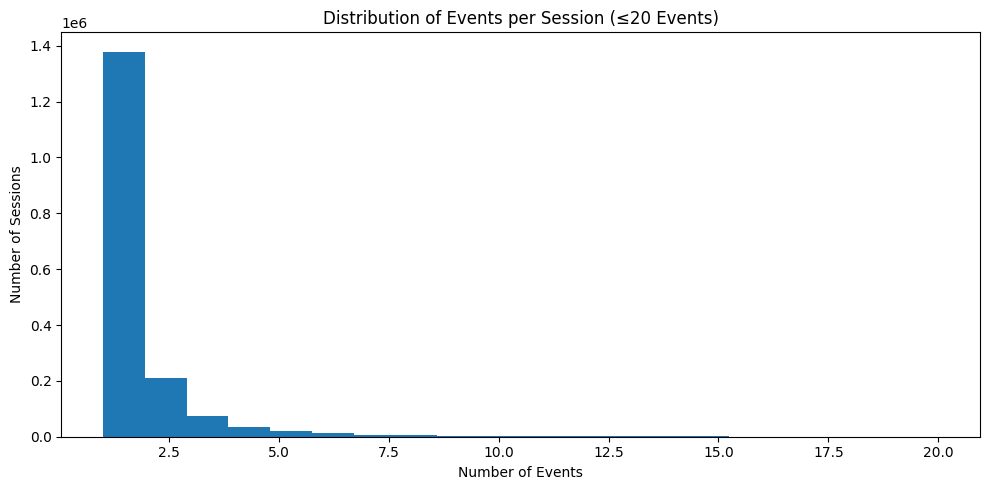

In [88]:
session_summary.loc[
    session_summary["event_count"] <= 20,
    "event_count"
].plot(
    kind="hist",
    bins=20,
    figsize=(10, 5)
)

plt.title("Distribution of Events per Session (≤20 Events)")
plt.xlabel("Number of Events")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

#### 7.4 Session Duration

Session duration was calculated as the elapsed time between the first and final recorded interaction within each session. Single-event sessions therefore have an observed duration of zero minutes, while multi-event sessions provide a measurable indication of the length of user activity.

In [89]:
multi_event_sessions = session_summary[
    session_summary["event_count"] > 1
]

multi_event_sessions["session_duration_minutes"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    382712.000000
mean          8.074163
std          16.371687
min           0.000000
25%           0.950946
50%           2.982892
75%           9.407950
90%          21.429460
95%          29.139843
99%          61.040976
max         728.404133
Name: session_duration_minutes, dtype: float64

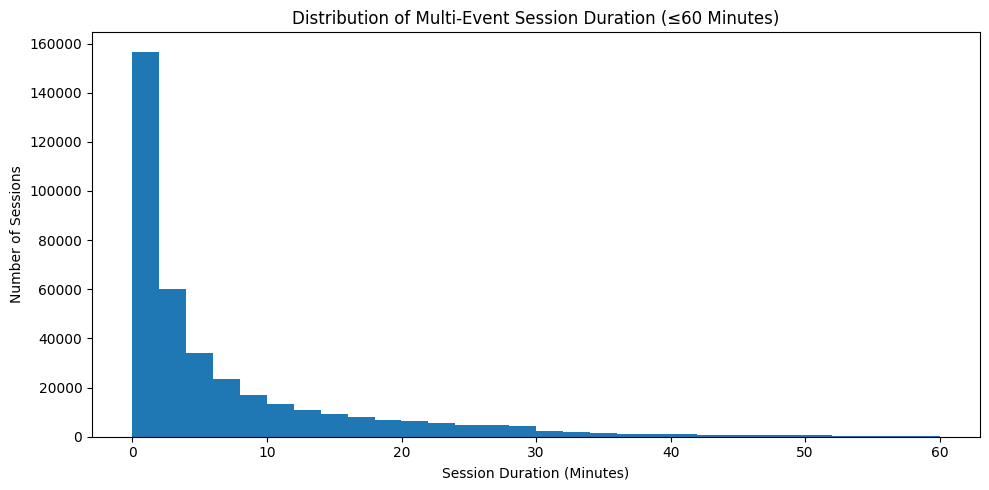

In [90]:
multi_event_sessions.loc[
    multi_event_sessions["session_duration_minutes"] <= 60,
    "session_duration_minutes"
].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5)
)

plt.title("Distribution of Multi-Event Session Duration (≤60 Minutes)")
plt.xlabel("Session Duration (Minutes)")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

#### 7.5 Unique Items per Session

The number of unique items interacted with during each session was examined as an indication of browsing breadth. Sessions involving a larger number of distinct items may represent greater product exploration, while sessions involving only one item may reflect more focused behaviour.

In [91]:
session_summary["unique_items"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1.761675e+06
mean     1.332739e+00
std      1.784379e+00
min      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
90%      2.000000e+00
95%      3.000000e+00
99%      6.000000e+00
max      3.890000e+02
Name: unique_items, dtype: float64

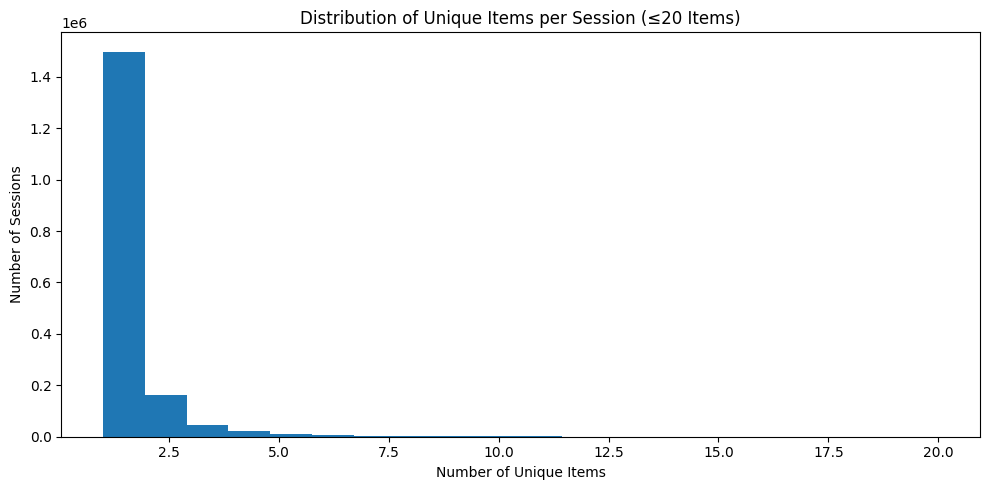

In [92]:
session_summary.loc[
    session_summary["unique_items"] <= 20,
    "unique_items"
].plot(
    kind="hist",
    bins=20,
    figsize=(10, 5)
)

plt.title("Distribution of Unique Items per Session (≤20 Items)")
plt.xlabel("Number of Unique Items")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

The distribution of unique items per session was strongly right-skewed. The median session contained only one unique item, with 75% of sessions also limited to a single item. Approximately 90% of sessions contained no more than two unique items, while only a small proportion involved substantially broader product exploration. This indicates that most sessions in the dataset represent relatively focused or limited browsing behaviour, with a smaller number of highly active sessions producing the long upper tail.

### 8. Session-Level Feature Engineering

Following session construction and exploratory analysis, event-level interactions were aggregated to create features representing user behaviour within each session. These features will form the basis of the session-level modelling dataset used for Bayesian Network structure learning and comparison with baseline classification models.

#### 8.1 Event-Type Features

The frequency of each event type was calculated for every session to represent different stages of user interaction. Views capture product browsing activity, add-to-cart events indicate stronger purchase intent, and transactions represent completed purchases. Aggregating these behaviours at session level allows differences in interaction patterns to be incorporated into subsequent modelling.

In [93]:
event_type_counts = (
    events.groupby(["session_id", "event"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

event_type_counts.head()

event,session_id,addtocart,transaction,view
0,0_1,0,0,3
1,1000000_1,0,0,1
2,1000001_1,0,0,1
3,1000001_2,0,0,3
4,1000001_3,0,0,1


In [94]:
event_type_counts.columns

Index(['session_id', 'addtocart', 'transaction', 'view'], dtype='object', name='event')

In [95]:
event_type_counts = event_type_counts.rename(
    columns={
        "view": "view_count",
        "addtocart": "addtocart_count",
        "transaction": "transaction_count"
    }
)

event_type_counts.head()

event,session_id,addtocart_count,transaction_count,view_count
0,0_1,0,0,3
1,1000000_1,0,0,1
2,1000001_1,0,0,1
3,1000001_2,0,0,3
4,1000001_3,0,0,1


In [96]:
session_features = session_summary.merge(
    event_type_counts,
    on="session_id",
    how="left"
)

session_features.head()

,session_id,visitorid,session_start,session_end,event_count,unique_items,session_duration_minutes,addtocart_count,transaction_count,view_count
0,0_1,0,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,3,3,5.462267,0,0,3
1,1000000_1,1000000,2015-06-05 18:16:10.629,2015-06-05 18:16:10.629,1,1,0.000000,0,0,1
2,1000001_1,1000001,2015-07-07 18:12:14.953,2015-07-07 18:12:14.953,1,1,0.000000,0,0,1
3,1000001_2,1000001,2015-07-24 20:18:15.303,2015-07-24 20:35:57.029,3,3,17.695433,0,0,3
4,1000001_3,1000001,2015-07-29 20:38:29.170,2015-07-29 20:38:29.170,1,1,0.000000,0,0,1


In [97]:
print(f"Sessions before merge: {len(session_summary):,}")
print(f"Sessions after merge: {len(session_features):,}")

session_features[
    ["view_count", "addtocart_count", "transaction_count"]
].describe()

Sessions before merge: 1,761,675
Sessions after merge: 1,761,675


,view_count,addtocart_count,transaction_count
count,1.761675e+06,1.761675e+06,1.761675e+06
mean,1.512321e+00,3.914797e-02,1.274753e-02
std,2.352375e+00,3.970118e-01,2.071244e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,0.000000e+00,0.000000e+00
max,4.170000e+02,1.140000e+02,5.900000e+01


In [98]:
event_count_check = (
    session_features["event_count"]
    ==
    (
        session_features["view_count"]
        + session_features["addtocart_count"]
        + session_features["transaction_count"]
    )
)

print(f"Sessions passing event count check: {event_count_check.sum():,}")
print(f"Sessions failing event count check: {(~event_count_check).sum():,}")

Sessions passing event count check: 1,761,675
Sessions failing event count check: 0


#### 8.2 Conversion Outcome

A binary conversion outcome was created to represent whether a purchase occurred within each session. A session was classified as converted if it contained at least one transaction event and as non-converted otherwise. This produces a binary target variable suitable for the subsequent Bayesian Network and baseline classification models.

In [99]:
session_features["converted"] = (
    session_features["transaction_count"] > 0
).astype(int)

session_features[
    ["session_id", "transaction_count", "converted"]
].head(10)

,session_id,transaction_count,converted
0,0_1,0,0
1,1000000_1,0,0
2,1000001_1,0,0
3,1000001_2,0,0
4,1000001_3,0,0
5,1000002_1,0,0
6,1000003_1,0,0
7,1000004_1,0,0
8,1000005_1,0,0
9,1000006_1,0,0


In [100]:
conversion_counts = session_features["converted"].value_counts().sort_index()

conversion_percentages = (
    session_features["converted"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Conversion counts:")
print(conversion_counts)

print("\nConversion percentages:")
print(conversion_percentages.round(2))

Conversion counts:
converted
0    1747378
1      14297
Name: count, dtype: int64

Conversion percentages:
converted
0    99.19
1     0.81
Name: proportion, dtype: float64


In [101]:
conversion_check = (
    ((session_features["transaction_count"] > 0) & (session_features["converted"] == 1))
    |
    ((session_features["transaction_count"] == 0) & (session_features["converted"] == 0))
)

print(f"Sessions passing conversion check: {conversion_check.sum():,}")
print(f"Sessions failing conversion check: {(~conversion_check).sum():,}")

Sessions passing conversion check: 1,761,675
Sessions failing conversion check: 0


The resulting conversion outcome was highly imbalanced. Of the 1,761,675 reconstructed sessions, 14,297 (0.81%) contained at least one transaction and were therefore classified as converted, while 1,747,378 (99.19%) were classified as non-converted. This substantial class imbalance will need to be considered during model training and evaluation, particularly because overall accuracy could provide a misleading indication of predictive performance.

#### 8.3 Behavioural Intent Features

Additional behavioural features were derived to distinguish sessions exhibiting stronger purchase intent from those involving browsing activity alone. In particular, the presence of an add-to-cart event was represented as a binary variable, allowing sessions that progressed beyond product viewing to be identified independently of the final conversion outcome.

In [102]:
session_features["has_addtocart"] = (
    session_features["addtocart_count"] > 0
).astype(int)

session_features[
    ["view_count", "addtocart_count", "has_addtocart", "converted"]
].head(10)

,view_count,addtocart_count,has_addtocart,converted
0,3,0,0,0
1,1,0,0,0
2,1,0,0,0
3,3,0,0,0
4,1,0,0,0
5,1,0,0,0
6,2,0,0,0
7,1,0,0,0
8,1,0,0,0
9,1,0,0,0


In [103]:
addtocart_distribution = (
    session_features["has_addtocart"]
    .value_counts()
    .sort_index()
)

addtocart_percentage = (
    session_features["has_addtocart"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Add-to-cart counts:")
print(addtocart_distribution)

print("\nAdd-to-cart percentages:")
print(addtocart_percentage.round(2))

Add-to-cart counts:
has_addtocart
0    1717751
1      43924
Name: count, dtype: int64

Add-to-cart percentages:
has_addtocart
0    97.51
1     2.49
Name: proportion, dtype: float64


In [104]:
cart_conversion = pd.crosstab(
    session_features["has_addtocart"],
    session_features["converted"],
    normalize="index"
) * 100

cart_conversion

converted,0,1
has_addtocart,,
0,99.862320,0.137680
1,72.834897,27.165103


Add-to-cart behaviour occurred in a relatively small proportion of sessions, with 43,924 sessions (2.49%) containing at least one add-to-cart event. However, a substantial difference in conversion behaviour was observed between the two groups. Only 0.14% of sessions without an add-to-cart event resulted in conversion, compared with 27.17% of sessions containing at least one add-to-cart event. This indicates a strong association between cart activity and conversion and supports the inclusion of add-to-cart behaviour as a potentially informative feature in subsequent modelling. This relationship is associative rather than causal and will be examined further through the learned Bayesian Network structure.

In [105]:
converted_sessions = session_features[
    session_features["converted"] == 1
]

converted_cart_distribution = (
    converted_sessions["has_addtocart"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Add-to-cart behaviour among converted sessions:")
print(converted_cart_distribution.round(2))

Add-to-cart behaviour among converted sessions:
has_addtocart
0    16.54
1    83.46
Name: proportion, dtype: float64


Among sessions that resulted in conversion, 83.46% contained at least one add-to-cart event, while 16.54% converted without an observed add-to-cart event within the same reconstructed session. This suggests that add-to-cart activity characterises the majority of converting sessions but is not a necessary precursor to conversion in the observed data. The presence of multiple behavioural pathways further supports examining dependencies between session behaviours using Bayesian Network structure learning.

#### 8.4 Temporal Features

Temporal characteristics were derived from the start time of each session to examine whether conversion behaviour varies according to when a session occurs. Hour of day and day of week were retained initially, alongside a binary weekend indicator. These variables provide potentially relevant contextual information without relying on information occurring after the start of the session.

In [106]:
session_features["session_hour"] = (
    session_features["session_start"].dt.hour
)

session_features["day_of_week"] = (
    session_features["session_start"].dt.day_name()
)

session_features["is_weekend"] = (
    session_features["session_start"].dt.dayofweek >= 5
).astype(int)

session_features[
    [
        "session_start",
        "session_hour",
        "day_of_week",
        "is_weekend"
    ]
].head(10)

,session_start,session_hour,day_of_week,is_weekend
0,2015-09-11 20:49:49.439,20,Friday,0
1,2015-06-05 18:16:10.629,18,Friday,0
2,2015-07-07 18:12:14.953,18,Tuesday,0
3,2015-07-24 20:18:15.303,20,Friday,0
4,2015-07-29 20:38:29.170,20,Wednesday,0
5,2015-07-16 20:01:11.884,20,Thursday,0
6,2015-08-13 08:32:44.125,8,Thursday,0
7,2015-06-19 23:20:06.086,23,Friday,0
8,2015-05-25 19:01:54.436,19,Monday,0
9,2015-06-15 17:54:07.397,17,Monday,0


In [107]:
print("Sessions by day of week:")
print(
    session_features["day_of_week"]
    .value_counts()
)

print("\nWeekend distribution:")
print(
    session_features["is_weekend"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Sessions by day of week:
day_of_week
Tuesday      283306
Monday       279320
Wednesday    273494
Thursday     266388
Friday       243992
Sunday       216374
Saturday     198801
Name: count, dtype: int64

Weekend distribution:
is_weekend
0    76.43
1    23.57
Name: proportion, dtype: float64


In [108]:
day_conversion = (
    session_features
    .groupby("day_of_week")["converted"]
    .agg(["count", "mean"])
)

day_conversion["conversion_rate_percent"] = (
    day_conversion["mean"] * 100
)

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_conversion = day_conversion.reindex(day_order)

day_conversion[
    ["count", "conversion_rate_percent"]
]

,count,conversion_rate_percent
day_of_week,,
Monday,279320,0.890735
Tuesday,283306,0.904676
Wednesday,273494,0.941885
Thursday,266388,0.848011
Friday,243992,0.752484
Saturday,198801,0.601104
Sunday,216374,0.637785


In [109]:
hour_conversion = (
    session_features
    .groupby("session_hour")["converted"]
    .agg(["count", "mean"])
)

hour_conversion["conversion_rate_percent"] = (
    hour_conversion["mean"] * 100
)

hour_conversion[
    ["count", "conversion_rate_percent"]
]

,count,conversion_rate_percent
session_hour,,
0,91131,0.781293
1,90345,0.732747
2,94461,0.693408
3,98549,0.622026
4,95313,0.619013
5,76916,0.635758
6,49987,0.604157
7,28466,0.562074
8,16907,0.396286


Temporal variation was observed in session-level conversion behaviour. Conversion rates were generally higher during the earlier part of the week, reaching approximately 0.94% on Wednesday, compared with 0.60% on Saturday and 0.64% on Sunday. This suggests that day of week may contain information relevant to conversion behaviour.

Conversion also varied across the hour of session initiation. Rates were lowest during the morning, falling to approximately 0.37–0.40% between 08:00 and 12:00, before increasing during the afternoon. The highest observed conversion rate occurred at 15:00 (approximately 1.13%), with relatively elevated rates continuing into the early evening. These patterns suggest that temporal characteristics may provide useful contextual features for subsequent modelling. However, the observed relationships are descriptive and do not imply that the timing of a session causes conversion.

#### 8.5 Session Duration and Conversion

Session duration was examined in relation to conversion to determine whether converting and non-converting sessions exhibit different levels of engagement. As session duration is highly right-skewed and contains a large proportion of zero-duration single-event sessions, both median and distributional statistics were considered rather than relying solely on the mean.

In [110]:
duration_by_conversion = (
    session_features
    .groupby("converted")["session_duration_minutes"]
    .describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

duration_by_conversion

,count,mean,std,min,50%,75%,90%,95%,99%,max
converted,,,,,,,,,,
0,1747378.0,1.532963,6.246475,0.0,0.000000,0.000000,3.146400,9.442142,28.220741,668.659233
1,14297.0,28.776160,55.100466,0.0,11.704317,28.473733,62.159413,116.838770,289.453809,728.404133


In [111]:
engagement_by_conversion = (
    session_features
    .groupby("converted")[
        [
            "event_count",
            "unique_items",
            "session_duration_minutes"
        ]
    ]
    .agg(["mean", "median"])
)

engagement_by_conversion

event_count        unique_items        session_duration_minutes  \
                 mean median         mean median                     mean   
converted                                                                   
0            1.500588    1.0     1.305021    1.0                 1.532963   
1            9.340841    4.0     4.720431    1.0                28.776160   

                      
              median  
converted             
0           0.000000  
1          11.704317

A substantial difference in engagement was observed between converting and non-converting sessions. Non-converting sessions had a median duration of 0 minutes and a mean duration of approximately 1.53 minutes, reflecting the large number of single-event sessions in the dataset. In contrast, converting sessions had a median duration of approximately 11.70 minutes and a mean duration of 28.78 minutes.

Converted sessions also contained considerably more activity. They contained an average of 9.34 events compared with 1.50 events for non-converted sessions, while the mean number of unique items was 4.72 compared with 1.31. The median event count was four for converted sessions compared with one for non-converted sessions.

These results indicate a strong association between greater session engagement and conversion. Session duration and event count therefore represent potentially informative variables for subsequent modelling. However, these relationships are descriptive rather than causal, and the continuous and highly skewed nature of the variables will require consideration during preprocessing for the Bayesian Network.

#### 8.6 Event Count and Conversion

The relationship between the number of events within a session and conversion was examined to assess whether conversion likelihood varies with increasing levels of session activity. Event counts were grouped into interpretable categories to account for the highly skewed distribution and to facilitate comparison between different levels of engagement.

In [112]:
event_bins = [0, 1, 2, 3, 5, 10, 20, float("inf")]
event_labels = [
    "1",
    "2",
    "3",
    "4–5",
    "6–10",
    "11–20",
    "21+"
]

session_features["event_count_group"] = pd.cut(
    session_features["event_count"],
    bins=event_bins,
    labels=event_labels,
    right=True
)

event_conversion = (
    session_features
    .groupby("event_count_group", observed=True)["converted"]
    .agg(["count", "sum", "mean"])
)

event_conversion["conversion_rate_percent"] = (
    event_conversion["mean"] * 100
)

event_conversion[
    ["count", "sum", "conversion_rate_percent"]
]

,count,sum,conversion_rate_percent
event_count_group,,,
1,1378963,535,0.038797
2,210696,1393,0.661142
3,74557,3290,4.412731
4–5,53345,3508,6.576061
6–10,31243,2913,9.323689
11–20,9414,1405,14.924580
21+,3457,1253,36.245299


A clear relationship was observed between session activity and conversion. Sessions containing only one event had a conversion rate of approximately 0.04%, increasing to 0.66% for two-event sessions and 4.41% for sessions containing three events. Conversion rates continued to increase with greater session activity, reaching 6.58% for sessions with 4–5 events, 9.32% for 6–10 events and 14.92% for 11–20 events.

The highest conversion rate was observed among sessions containing more than 20 events, of which approximately 36.25% resulted in conversion. This demonstrates a strong positive association between the level of within-session activity and conversion. Event count therefore appears to be a potentially informative predictor of conversion.

However, the distribution of event counts is highly imbalanced, with the majority of sessions containing only one event. The relationship should therefore be interpreted as associative rather than causal. The grouped results also provide an empirical basis for considering discretisation of event count when preparing variables for Bayesian Network modelling.

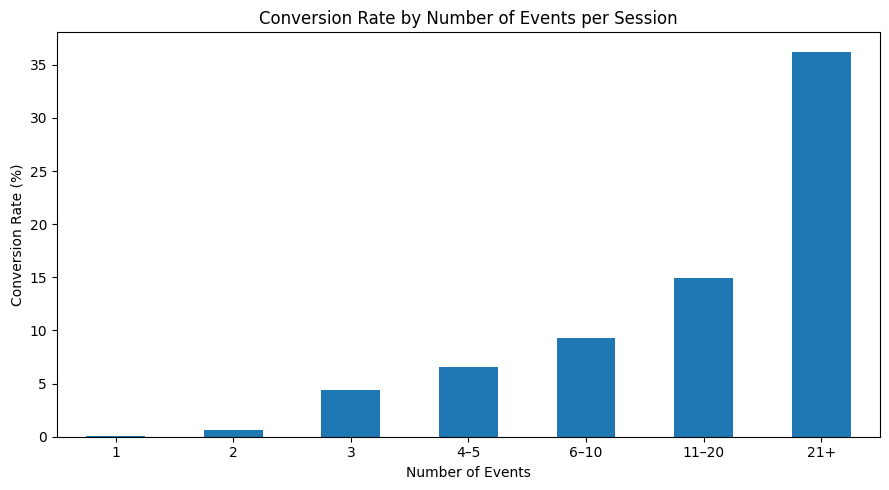

In [113]:
import matplotlib.pyplot as plt

event_conversion["conversion_rate_percent"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Conversion Rate by Number of Events per Session")
plt.xlabel("Number of Events")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 8.7 Unique Items and Conversion

The number of unique items viewed within each session was examined in relation to conversion. This provides an indication of whether broader product exploration is associated with conversion behaviour. As the distribution of unique items is highly skewed, values were grouped into categories to facilitate comparison across different levels of product exploration.

In [114]:
item_bins = [0, 1, 2, 3, 5, 10, 20, float("inf")]
item_labels = [
    "1",
    "2",
    "3",
    "4–5",
    "6–10",
    "11–20",
    "21+"
]

session_features["unique_items_group"] = pd.cut(
    session_features["unique_items"],
    bins=item_bins,
    labels=item_labels,
    right=True
)

item_conversion = (
    session_features
    .groupby("unique_items_group", observed=True)["converted"]
    .agg(["count", "sum", "mean"])
)

item_conversion["conversion_rate_percent"] = (
    item_conversion["mean"] * 100
)

item_conversion[
    ["count", "sum", "conversion_rate_percent"]
]

,count,sum,conversion_rate_percent
unique_items_group,,,
1,1497776,7344,0.490327
2,162966,2327,1.427905
3,47367,1139,2.404628
4–5,31271,1135,3.629561
6–10,16158,1053,6.516896
11–20,4403,597,13.558937
21+,1734,702,40.484429


A clear positive relationship was observed between the number of unique items within a session and conversion. Sessions involving only one unique item had a conversion rate of approximately 0.49%, increasing to 1.43% for two items and 2.40% for three items. Conversion rates continued to rise as the number of distinct items increased, reaching 6.52% for sessions containing 6–10 unique items and 13.56% for sessions containing 11–20 unique items.

The highest conversion rate was observed among sessions containing more than 20 unique items, with approximately 40.48% of these sessions resulting in conversion. This suggests that greater product exploration is strongly associated with conversion behaviour.

However, sessions containing large numbers of unique items were relatively uncommon, with only 1,734 sessions in the 21+ category compared with approximately 1.50 million sessions containing a single unique item. The high conversion rate within this group should therefore be interpreted alongside its substantially smaller sample size. Overall, unique item count appears to be a potentially informative variable for subsequent modelling, while the skewed distribution supports consideration of discretisation prior to Bayesian Network learning.

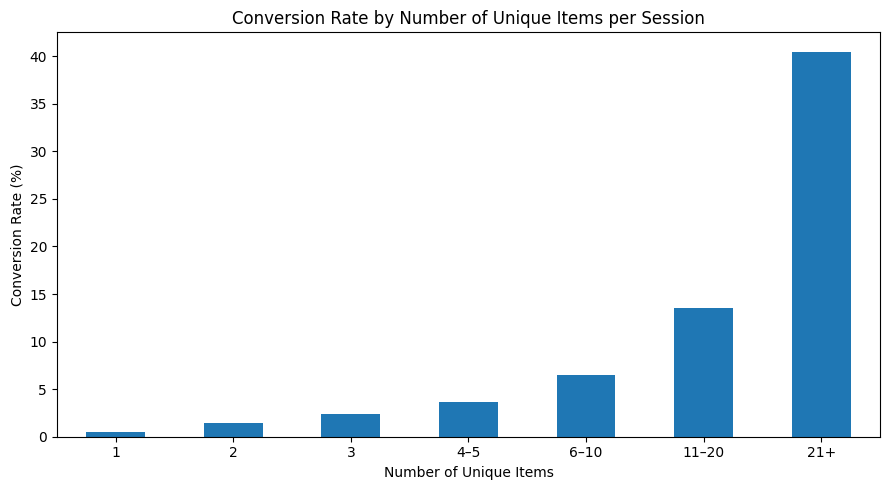

In [115]:
item_conversion["conversion_rate_percent"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Conversion Rate by Number of Unique Items per Session")
plt.xlabel("Number of Unique Items")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 8.8 Summary of Session-Level Findings

The session-level exploratory analysis identified several behavioural characteristics associated with conversion. The resulting dataset contained approximately 1.76 million sessions, with conversion occurring in only 0.81% of sessions, indicating substantial class imbalance. Most sessions were short and contained relatively few events and unique items, while a smaller proportion exhibited substantially greater engagement.

Conversion was strongly associated with several measures of session activity. Sessions containing add-to-cart behaviour had a substantially higher conversion rate than those without such behaviour, while conversion rates also increased progressively with both the number of events and the number of unique items within a session. Converting sessions additionally tended to have longer durations and greater overall engagement than non-converting sessions.

Temporal variation in conversion was also observed across days of the week and hours of the day, suggesting that temporal characteristics may provide additional information for modelling. Overall, the exploratory analysis supports the inclusion of behavioural, engagement and temporal variables in the subsequent modelling stage. The strong skewness of several continuous/count variables and the substantial imbalance in the conversion outcome will be considered during preprocessing and model development.

### 9. Bayesian Network Preparation

This section prepares the session-level dataset for Bayesian Network modelling. The exploratory analysis identified several behavioural, engagement and temporal characteristics associated with conversion. Before structure learning, candidate variables are selected, potential target leakage is considered, and variables are transformed into representations suitable for discrete Bayesian Network modelling.

#### 9.1 Candidate Modelling Variables

Candidate variables were selected based on the exploratory analysis and their potential to represent different aspects of customer behaviour within a session. The target variable is `converted`, which indicates whether at least one transaction occurred during the session.

The initial candidate predictors represent session engagement, product exploration, cart behaviour and temporal characteristics. Variables that directly encode the occurrence of a transaction are excluded from the predictor set to prevent target leakage.

| Variable | Description | Initial role |
|---|---|---|
| `event_count` | Total number of events within the session | Predictor |
| `unique_items` | Number of distinct items interacted with | Predictor |
| `session_duration_minutes` | Duration of the session in minutes | Predictor |
| `has_addtocart` | Whether the session contained an add-to-cart event | Predictor |
| `session_hour` | Hour in which the session began | Predictor |
| `day_of_week` | Day on which the session began | Predictor |
| `is_weekend` | Whether the session occurred on Saturday or Sunday | Candidate predictor |
| `converted` | Whether the session contained a transaction | Target |
| `transaction_count` | Number of transaction events | Excluded – target leakage |

#### 9.2 Target Leakage

Target leakage occurs when a predictor contains information that directly or indirectly reveals the outcome being predicted. This can result in unrealistically strong model performance and reduce the validity of the resulting model.

In the session-level dataset, `converted` was defined as 1 when `transaction_count` was greater than zero and 0 otherwise. Consequently, `transaction_count` directly determines the target variable and must not be used as a predictor. The variable is therefore retained only for validation purposes and excluded from the Bayesian Network predictor set.

Other candidate variables describe behaviour occurring within the session rather than directly defining the conversion outcome. Their suitability for inclusion will be considered further during preprocessing and discretisation.

In [116]:
# Confirm relationship between transaction_count and converted
pd.crosstab(
    session_features["transaction_count"] > 0,
    session_features["converted"]
)

converted,0,1
transaction_count,,
False,1747378,0
True,0,14297


In [117]:
candidate_variables = [
    "event_count",
    "unique_items",
    "session_duration_minutes",
    "has_addtocart",
    "session_hour",
    "day_of_week",
    "is_weekend",
    "converted"
]

bn_data = session_features[candidate_variables].copy()

bn_data.head()

,event_count,unique_items,session_duration_minutes,has_addtocart,session_hour,day_of_week,is_weekend,converted
0,3,3,5.462267,0,20,Friday,0,0
1,1,1,0.000000,0,18,Friday,0,0
2,1,1,0.000000,0,18,Tuesday,0,0
3,3,3,17.695433,0,20,Friday,0,0
4,1,1,0.000000,0,20,Wednesday,0,0


In [118]:
print(f"Number of sessions: {len(bn_data):,}")
print(f"Number of variables: {bn_data.shape[1]}")

bn_data.dtypes

Number of sessions: 1,761,675
Number of variables: 8


event_count                   int64
unique_items                  int64
session_duration_minutes    float64
has_addtocart                 int64
session_hour                  int32
day_of_week                  object
is_weekend                    int64
converted                     int64
dtype: object

#### 9.3 Discretisation Strategy

The Bayesian Network will be constructed using discrete variables. Consequently, continuous and high-cardinality count variables require transformation into a smaller number of meaningful states before structure and parameter learning.

Discretisation was informed by the distributions identified during exploratory analysis rather than applying the same method to every variable. This approach preserves interpretable behavioural categories while limiting the number of states required for Conditional Probability Table estimation.

Binary variables (`has_addtocart`, `is_weekend` and `converted`) are already discrete and therefore require no transformation. Categorical and temporal variables are considered separately below.

In [119]:
# Review distributions of variables requiring discretisation
bn_data[
    ["event_count", "unique_items", "session_duration_minutes"]
].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,event_count,unique_items,session_duration_minutes
count,1.761675e+06,1.761675e+06,1.761675e+06
mean,1.564216e+00,1.332739e+00,1.754057e+00
std,2.599172e+00,1.784379e+00,8.325496e+00
min,1.000000e+00,1.000000e+00,0.000000e+00
50%,1.000000e+00,1.000000e+00,0.000000e+00
75%,1.000000e+00,1.000000e+00,0.000000e+00
90%,2.000000e+00,2.000000e+00,3.552707e+00
95%,4.000000e+00,3.000000e+00,1.040246e+01
99%,9.000000e+00,6.000000e+00,2.987564e+01
max,4.170000e+02,3.890000e+02,7.284041e+02


In [120]:
# Examine session hour distribution
bn_data["session_hour"].value_counts().sort_index()

session_hour
0      91131
1      90345
2      94461
3      98549
4      95313
5      76916
6      49987
7      28466
8      16907
9      12377
10     11582
11     14501
12     22290
13     35750
14     56056
15     82187
16    101647
17    112516
18    113112
19    114886
20    116454
21    114733
22    110614
23    100895
Name: count, dtype: int64

In [121]:
pd.crosstab(
    bn_data["day_of_week"],
    bn_data["is_weekend"]
)

is_weekend,0,1
day_of_week,,
Friday,243992,0
Monday,279320,0
Saturday,0,198801
Sunday,0,216374
Thursday,266388,0
Tuesday,283306,0
Wednesday,273494,0


#### Discretisation Decisions

The distributions demonstrate substantial right-skewness in the session-level engagement variables. At least 75% of sessions contained only one event and one unique item, while 75% had a recorded duration of zero minutes. Consequently, conventional equal-width or quantile-based discretisation would provide limited separation between the majority of sessions.

Behaviourally interpretable thresholds were therefore used to create a relatively small number of discrete states. Event count and unique-item count were grouped into single-interaction, moderate-interaction and higher-interaction categories. Session duration retained zero-duration sessions as a distinct state because these represent a substantial proportion of the dataset, while positive-duration sessions were divided into progressively longer categories.

Session hour was grouped into broad time-of-day periods to reduce the original 24 states. Day of week was retained as a categorical variable. The `is_weekend` variable was excluded because it is deterministically derived from `day_of_week` and therefore provides redundant information.

In [122]:
bn_discrete = bn_data.copy()

# Event count
bn_discrete["event_count"] = pd.cut(
    bn_discrete["event_count"],
    bins=[0, 1, 3, float("inf")],
    labels=["1", "2-3", "4+"]
)

# Unique items
bn_discrete["unique_items"] = pd.cut(
    bn_discrete["unique_items"],
    bins=[0, 1, 3, float("inf")],
    labels=["1", "2-3", "4+"]
)

# Session duration
bn_discrete["session_duration"] = pd.cut(
    bn_discrete["session_duration_minutes"],
    bins=[-0.001, 0, 5, 15, float("inf")],
    labels=["0", "0-5", "5-15", "15+"]
)

In [123]:
def categorise_time(hour):
    if 0 <= hour < 6:
        return "night"
    elif 6 <= hour < 12:
        return "morning"
    elif 12 <= hour < 18:
        return "afternoon"
    else:
        return "evening"

bn_discrete["time_of_day"] = (
    bn_discrete["session_hour"]
    .apply(categorise_time)
)

In [124]:
bn_discrete.columns

Index(['event_count', 'unique_items', 'session_duration_minutes',
       'has_addtocart', 'session_hour', 'day_of_week', 'is_weekend',
       'converted', 'session_duration', 'time_of_day'],
      dtype='object')

In [125]:
# Remove continuous and redundant variables after discretisation
bn_discrete = bn_discrete.drop(
    columns=[
        "session_duration_minutes",
        "session_hour",
        "is_weekend"
    ]
)

print("Final Bayesian Network variables:")
print(bn_discrete.columns.tolist())

print(f"\nFinal dataset shape: {bn_discrete.shape}")

print("\nMissing values:")
print(bn_discrete.isnull().sum())

Final Bayesian Network variables:
['event_count', 'unique_items', 'has_addtocart', 'day_of_week', 'converted', 'session_duration', 'time_of_day']

Final dataset shape: (1761675, 7)

Missing values:
event_count         0
unique_items        0
has_addtocart       0
day_of_week         0
converted           0
session_duration    0
time_of_day         0
dtype: int64


In [126]:
for column in bn_discrete.columns:
    print(f"\n{column}")
    print(bn_discrete[column].value_counts(dropna=False))


event_count
event_count
1      1378963
2-3     285253
4+       97459
Name: count, dtype: int64

unique_items
unique_items
1      1497776
2-3     210333
4+       53566
Name: count, dtype: int64

has_addtocart
has_addtocart
0    1717751
1      43924
Name: count, dtype: int64

day_of_week
day_of_week
Tuesday      283306
Monday       279320
Wednesday    273494
Thursday     266388
Friday       243992
Sunday       216374
Saturday     198801
Name: count, dtype: int64

converted
converted
0    1747378
1      14297
Name: count, dtype: int64

session_duration
session_duration
0       1379142
0-5      235900
5-15      84847
15+       61786
Name: count, dtype: int64

time_of_day
time_of_day
evening      670694
night        546715
afternoon    410446
morning      133820
Name: count, dtype: int64


In [127]:
print("Missing values after discretisation:")
print(bn_discrete.isnull().sum())

print(f"\nFinal dataset shape: {bn_discrete.shape}")

Missing values after discretisation:
event_count         0
unique_items        0
has_addtocart       0
day_of_week         0
converted           0
session_duration    0
time_of_day         0
dtype: int64

Final dataset shape: (1761675, 7)


#### 9.4 Class Imbalance Strategy

The session-level conversion target is highly imbalanced, with converted sessions representing only 0.81% of the reconstructed dataset. This imbalance requires particular consideration during model training and evaluation because a classifier predicting the majority class for every observation would achieve high overall accuracy while providing little practical value.

The original class distribution will therefore be preserved for the primary Bayesian Network analysis so that learned probability estimates reflect the observed conversion prevalence within the dataset. Artificial oversampling of converted sessions will not be applied before Bayesian Network parameter estimation, as this would alter the empirical class probabilities from which the Conditional Probability Tables are estimated.

Class imbalance will instead be addressed primarily through model evaluation. Performance measures that account for minority-class prediction, including precision, recall, F1-score, ROC-AUC and precision-recall AUC, will be considered alongside probability calibration measures. Where appropriate, class weighting or resampling may be investigated separately for baseline classification models, with any such procedures applied only to the training data.

In [128]:
majority_accuracy = (
    bn_discrete["converted"].value_counts(normalize=True).max()
)

print(
    f"Accuracy from always predicting non-conversion: "
    f"{majority_accuracy * 100:.2f}%"
)

Accuracy from always predicting non-conversion: 99.19%


A classifier predicting non-conversion for every session would achieve approximately 99.19% accuracy. Consequently, accuracy alone is not an appropriate measure of model effectiveness for this prediction task, and evaluation will place greater emphasis on minority-class discrimination and probability quality.

#### 9.5 Save Final Modelling Datasets

The final session-level datasets were saved for use in subsequent modelling notebooks. Both the original session-level feature dataset and the discretised Bayesian Network dataset were retained so that baseline models and Bayesian Network models can use the representation most appropriate to each modelling approach.

Saving these processed datasets also avoids repeating the full preprocessing and sessionisation workflow during model development.

In [129]:
# Save continuous/session-level feature dataset
session_features.to_csv(
    "../data/processed/session_features.csv",
    index=False
)

# Save discretised Bayesian Network dataset
bn_discrete.to_csv(
    "../data/processed/bn_discrete.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [130]:
# Reload saved datasets to verify successful export
session_features_check = pd.read_csv(
    "../data/processed/session_features.csv"
)

bn_discrete_check = pd.read_csv(
    "../data/processed/bn_discrete.csv"
)

print(
    f"session_features.csv shape: "
    f"{session_features_check.shape}"
)

print(
    f"bn_discrete.csv shape: "
    f"{bn_discrete_check.shape}"
)

session_features.csv shape: (1761675, 17)
bn_discrete.csv shape: (1761675, 7)
